# **AlexNet Implementation**

## Step 1: Environment Setup & GPU Check

In [ ]:
import tensorflow as tf

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {tf.keras.__version__}")

# List GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(f"GPU detected       : {gpu.name}")
    # Allow memory growth (prevents OOM on shared GPUs)
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth      : enabled")
else:
    print("No GPU detected — running on CPU (slower)")
    print("Tip: Runtime → Change runtime type → T4 GPU")

TensorFlow version : 2.20.0
Keras version      : 3.13.2
GPU detected       : /physical_device:GPU:0
Memory growth      : enabled


## Step 2: Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import os
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 3: Hyperparameters & Configuration

In [ ]:
CONFIG = {
    # Data
    'img_size'       : 32,
    'num_channels'   : 3,
    'num_classes'    : 10,
    'val_split'      : 0.1,

    # Training
    'batch_size'     : 128,
    'num_epochs'     : 10,
    'learning_rate'  : 0.001,
    'weight_decay'   : 5e-4,
    'momentum'       : 0.9,
    'dropout_rate'   : 0.5,

    # LR Schedule
    'lr_decay_epochs': [10, 20],   # Reduce LR at these epochs
    'lr_decay_factor': 0.1,

    # Paths
    'save_path'      : 'alexnet_cifar10_best.keras',
}

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k:<20}: {v}")

Configuration:
  img_size            : 32
  num_channels        : 3
  num_classes         : 10
  val_split           : 0.1
  batch_size          : 128
  num_epochs          : 10
  learning_rate       : 0.001
  weight_decay        : 0.0005
  momentum            : 0.9
  dropout_rate        : 0.5
  lr_decay_epochs     : [10, 20]
  lr_decay_factor     : 0.1
  save_path           : alexnet_cifar10_best.keras


## Step 4: Load & Preprocess CIFAR-10

In [ ]:
# ─── Load dataset ──────────────────────────────────────────────────
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

# ─── Normalize to [0, 1] ───────────────────────────────────────────
x_train_full = x_train_full.astype('float32') / 255.0
x_test       = x_test.astype('float32') / 255.0

# ─── Per-channel standardization (CIFAR-10 mean & std) ────────────
CIFAR10_MEAN = np.array([0.4914, 0.4822, 0.4465], dtype='float32')
CIFAR10_STD  = np.array([0.2470, 0.2435, 0.2616], dtype='float32')

x_train_full = (x_train_full - CIFAR10_MEAN) / CIFAR10_STD
x_test       = (x_test       - CIFAR10_MEAN) / CIFAR10_STD

# ─── One-hot encode labels ─────────────────────────────────────────
y_train_full_oh = keras.utils.to_categorical(y_train_full, CONFIG['num_classes'])
y_test_oh       = keras.utils.to_categorical(y_test,       CONFIG['num_classes'])

# ─── Train / Validation split ──────────────────────────────────────
val_size  = int(len(x_train_full) * CONFIG['val_split'])
x_val,   y_val   = x_train_full[:val_size],  y_train_full_oh[:val_size]
x_train, y_train = x_train_full[val_size:],  y_train_full_oh[val_size:]

print(f"Train   : {x_train.shape}  labels: {y_train.shape}")
print(f"Val     : {x_val.shape}  labels: {y_val.shape}")
print(f"Test    : {x_test.shape}  labels: {y_test_oh.shape}")
print(f"Classes : {CLASS_NAMES}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train   : (45000, 32, 32, 3)  labels: (45000, 10)
Val     : (5000, 32, 32, 3)  labels: (5000, 10)
Test    : (10000, 32, 32, 3)  labels: (10000, 10)
Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Step 5: Data Augmentation with ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(
    width_shift_range  = 0.1,       # Random horizontal shift
    height_shift_range = 0.1,       # Random vertical shift
    horizontal_flip    = True,      # Random horizontal flip
    rotation_range     = 10,        # Random rotation ±10°
    zoom_range         = 0.1,       # Random zoom
    fill_mode          = 'nearest', # Fill strategy for new pixels
)

# No augmentation for validation/test
val_datagen  = ImageDataGenerator()

train_generator = train_datagen.flow(
    x_train, y_train,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow(
    x_val, y_val,
    batch_size=CONFIG['batch_size'],
    shuffle=False
)

steps_per_epoch  = len(x_train)  // CONFIG['batch_size']
validation_steps = len(x_val)    // CONFIG['batch_size']

print(f"Steps per epoch  : {steps_per_epoch}")
print(f"Validation steps : {validation_steps}")
print("Augmentation: shift, flip, rotation, zoom")

Steps per epoch  : 351
Validation steps : 39
Augmentation: shift, flip, rotation, zoom


## Step 6: Visualize Training Samples

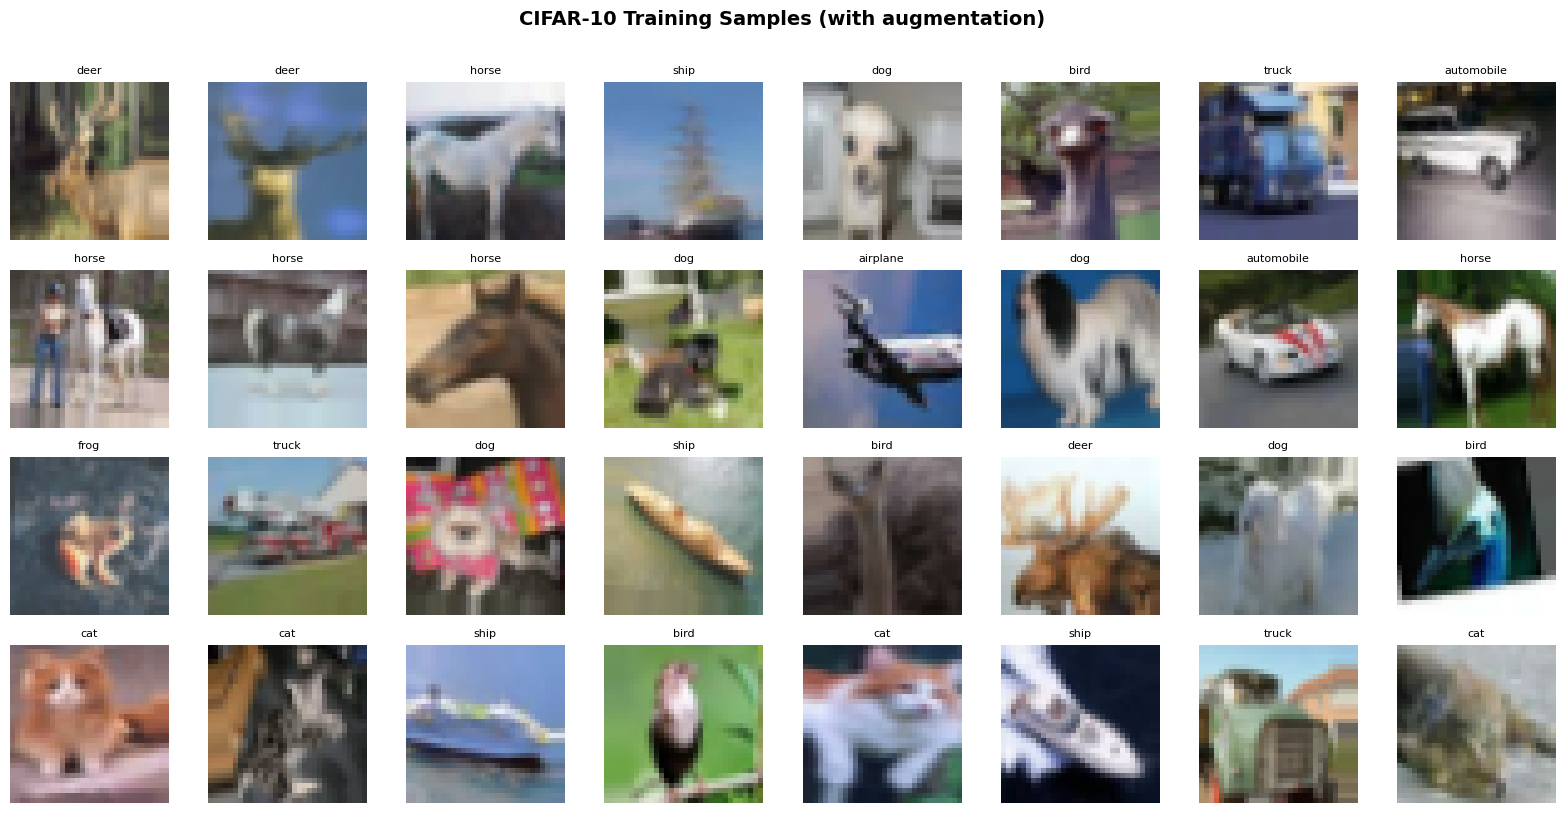

Image batch shape: (128, 32, 32, 3)  →  (batch, H, W, C)


In [ ]:
def denormalize(images):
    """Reverse normalization for display."""
    return np.clip(images * CIFAR10_STD + CIFAR10_MEAN, 0, 1)

# Grab one augmented batch
sample_imgs, sample_labels = next(train_generator)
sample_labels_idx = sample_labels.argmax(axis=1)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('CIFAR-10 Training Samples (with augmentation)',
             fontsize=14, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(sample_imgs[i]))
    ax.set_title(CLASS_NAMES[sample_labels_idx[i]], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f"Image batch shape: {sample_imgs.shape}  →  (batch, H, W, C)")

## Step 7: Build AlexNet Model

We use the **Keras Functional API** for clarity and flexibility.

In [ ]:
def build_alexnet(input_shape=(32, 32, 3),
                  num_classes=10,
                  dropout_rate=0.5,
                  weight_decay=5e-4):
    """
    AlexNet adapted for CIFAR-10 using Keras Functional API.

    Original: Krizhevsky et al., NeurIPS 2012
    Adaptations:
      - Smaller kernels (3x3) and no large-stride convolutions
      - BatchNorm replaces Local Response Normalization
      - L2 weight regularization on conv/dense layers
    """
    reg = regularizers.l2(weight_decay)

    inputs = keras.Input(shape=input_shape, name='input')

    # ── Block 1 ────────────────────────────────────────────────────
    x = layers.Conv2D(64, 3, padding='same', use_bias=False,
                      kernel_regularizer=reg, name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.MaxPooling2D(2, strides=2, name='pool1')(x)          # → 16×16×64

    # ── Block 2 ────────────────────────────────────────────────────
    x = layers.Conv2D(192, 3, padding='same', use_bias=False,
                      kernel_regularizer=reg, name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.MaxPooling2D(2, strides=2, name='pool2')(x)          # → 8×8×192

    # ── Block 3 ────────────────────────────────────────────────────
    x = layers.Conv2D(384, 3, padding='same', use_bias=False,
                      kernel_regularizer=reg, name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)                  # → 8×8×384

    # ── Block 4 ────────────────────────────────────────────────────
    x = layers.Conv2D(256, 3, padding='same', use_bias=False,
                      kernel_regularizer=reg, name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.Activation('relu', name='relu4')(x)                  # → 8×8×256

    # ── Block 5 ────────────────────────────────────────────────────
    x = layers.Conv2D(256, 3, padding='same', use_bias=False,
                      kernel_regularizer=reg, name='conv5')(x)
    x = layers.BatchNormalization(name='bn5')(x)
    x = layers.Activation('relu', name='relu5')(x)
    x = layers.MaxPooling2D(2, strides=2, name='pool5')(x)          # → 4×4×256

    # ── Classifier ─────────────────────────────────────────────────
    x = layers.Flatten(name='flatten')(x)                           # → 4096

    x = layers.Dropout(dropout_rate, name='drop1')(x)
    x = layers.Dense(4096, kernel_regularizer=reg, name='fc1')(x)
    x = layers.Activation('relu', name='relu_fc1')(x)

    x = layers.Dropout(dropout_rate, name='drop2')(x)
    x = layers.Dense(4096, kernel_regularizer=reg, name='fc2')(x)
    x = layers.Activation('relu', name='relu_fc2')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name='AlexNet')


model = build_alexnet(
    input_shape  = (CONFIG['img_size'], CONFIG['img_size'], CONFIG['num_channels']),
    num_classes  = CONFIG['num_classes'],
    dropout_rate = CONFIG['dropout_rate'],
    weight_decay = CONFIG['weight_decay'],
)

model.summary(line_length=75)

Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape            ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ input (InputLayer)             │ (None, 32, 32, 3)       │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ conv1 (Conv2D)                 │ (None, 32, 32, 64)      │        1,728 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ bn1 (BatchNormalization)       │ (None, 32, 32, 64)      │          256 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ relu1 (Activation)             │ (None, 32, 32, 64)      │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ pool1 (MaxPooling2D)           │ (None, 16, 16, 64)      │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ conv2 (Conv2D)                 │ (None, 16, 16, 192)     │      110,592 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ bn2 (BatchNormalization)       │ (None, 16, 16, 192)     │          768 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ relu2 (Activation)             │ (None, 16, 16, 192)     │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ pool2 (MaxPooling2D)           │ (None, 8, 8, 192)       │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ conv3 (Conv2D)                 │ (None, 8, 8, 384)       │      663,552 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ bn3 (BatchNormalization)       │ (None, 8, 8, 384)       │        1,536 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ relu3 (Activation)             │ (None, 8, 8, 384)       │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ conv4 (Conv2D)                 │ (None, 8, 8, 256)       │      884,736 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ bn4 (BatchNormalization)       │ (None, 8, 8, 256)       │        1,024 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ relu4 (Activation)             │ (None, 8, 8, 256)       │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ conv5 (Conv2D)                 │ (None, 8, 8, 256)       │      589,824 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ bn5 (BatchNormalization)       │ (None, 8, 8, 256)       │        1,024 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ relu5 (Activation)             │ (None, 8, 8, 256)       │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ pool5 (MaxPooling2D)           │ (None, 4, 4, 256)       │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ flatten (Flatten)              │ (None, 4096)            │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ drop1 (Dropout)                │ (None, 4096)            │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ fc1 (Dense)                    │ (None, 4096)            │   16,781,312 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ relu_fc1 (Activation)          │ (None, 4096)            │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ drop2 (Dropout)                │ (None, 4096)            │            0 │
├────────────────────────────────┼─────────────────────────┼──────────────┤
│ fc2 (Dense)                    │ (None, 4096)            │   16,781,312 │
├────────────────────────────────┼──────────────

 Total params: 35,858,634 (136.79 MB)

 Trainable params: 35,856,330 (136.78 MB)

 Non-trainable params: 2,304 (9.00 KB)

## Step 8: Visualize Model Architecture

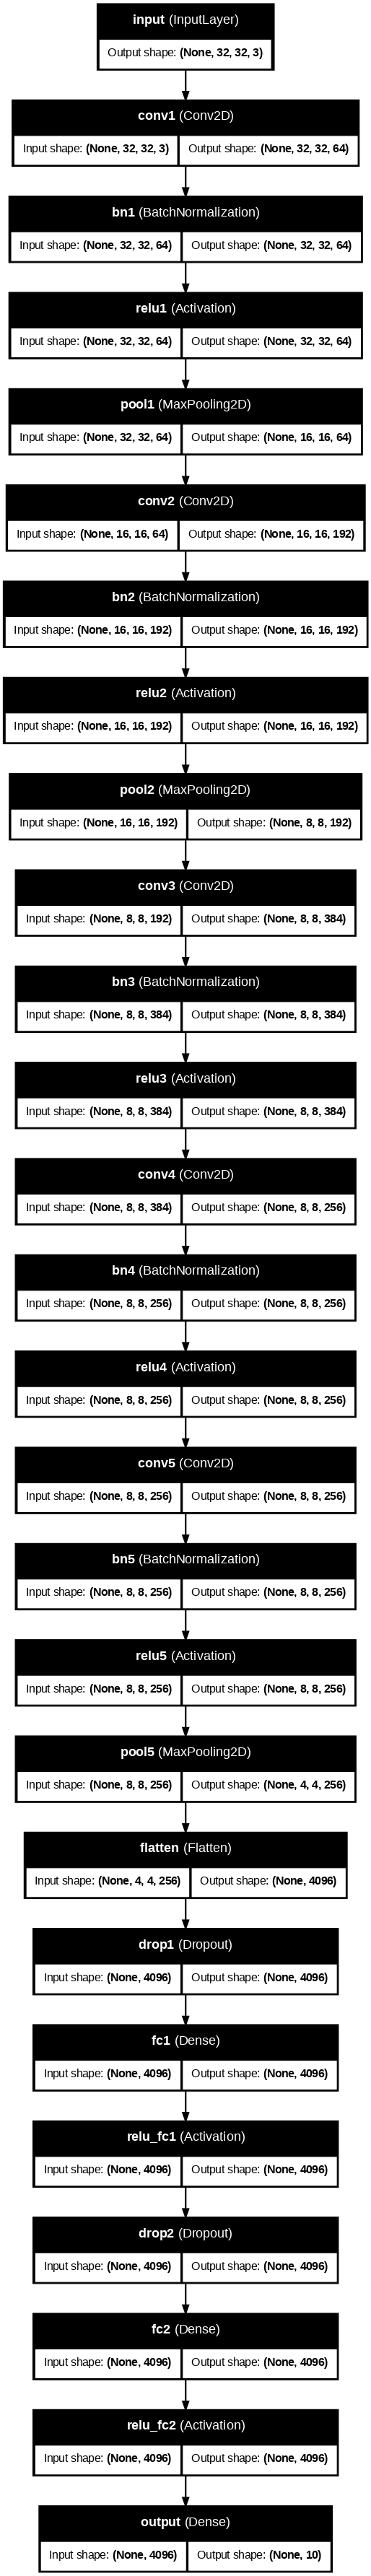

In [ ]:
keras.utils.plot_model(
    model,
    to_file='alexnet_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=80,
)

from IPython.display import Image
Image('alexnet_architecture.png')

## Step 9: Compile Model

In [ ]:
# ─── Optimizer ─────────────────────────────────────────────────────
optimizer = optimizers.SGD(
    learning_rate = CONFIG['learning_rate'],
    momentum      = CONFIG['momentum'],
    nesterov      = True,
)

# ─── Compile ───────────────────────────────────────────────────────
model.compile(
    optimizer = optimizer,
    loss      = keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics   = ['accuracy'],
)

# Parameter count
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f"Optimizer         : SGD (lr={CONFIG['learning_rate']}, momentum={CONFIG['momentum']}, nesterov=True)")
print(f"Loss              : CategoricalCrossentropy (label_smoothing=0.1)")
print(f"Total params      : {total_params:,}")
print(f"Trainable params  : {trainable_params:,}")
print(f"Model size (MB)   : {total_params * 4 / 1e6:.2f}")

Optimizer         : SGD (lr=0.001, momentum=0.9, nesterov=True)
Loss              : CategoricalCrossentropy (label_smoothing=0.1)
Total params      : 35,858,634
Trainable params  : 35,856,330
Model size (MB)   : 143.43


## Step 10: Define Callbacks

In [ ]:
# ── 1. Save best model ────────────────────────────────────────────
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath        = CONFIG['save_path'],
    monitor         = 'val_accuracy',
    mode            = 'max',
    save_best_only  = True,
    verbose         = 1,
)

# ── 2. Early stopping ─────────────────────────────────────────────
earlystop_cb = callbacks.EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 10,
    restore_best_weights = True,
    verbose              = 1,
)

# ── 3. Learning rate schedule (step decay) ────────────────────────
def lr_schedule(epoch, lr):
    if epoch in CONFIG['lr_decay_epochs']:
        new_lr = lr * CONFIG['lr_decay_factor']
        print(f"\nEpoch {epoch}: reducing LR {lr:.6f} → {new_lr:.6f}")
        return new_lr
    return lr

lr_scheduler_cb = callbacks.LearningRateScheduler(lr_schedule, verbose=0)

# ── 4. Reduce LR on plateau (backup) ─────────────────────────────
reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor   = 'val_loss',
    factor    = 0.5,
    patience  = 5,
    min_lr    = 1e-6,
    verbose   = 1,
)

# ── 5. TensorBoard logging ────────────────────────────────────────
tensorboard_cb = callbacks.TensorBoard(
    log_dir        = './logs',
    histogram_freq = 1,
    write_graph    = True,
)

all_callbacks = [
    checkpoint_cb,
    earlystop_cb,
    lr_scheduler_cb,
    reduce_lr_cb,
    tensorboard_cb,
]

print("Callbacks configured:")
for cb in all_callbacks:
    print(f"  ✓ {cb.__class__.__name__}")

Callbacks configured:
  ✓ ModelCheckpoint
  ✓ EarlyStopping
  ✓ LearningRateScheduler
  ✓ ReduceLROnPlateau
  ✓ TensorBoard


## Step 11: Train the Model

In [ ]:
print("Starting training...")
print("=" * 60)

start_time = time.time()

history = model.fit(
    train_generator,
    steps_per_epoch  = steps_per_epoch,
    epochs           = CONFIG['num_epochs'],
    validation_data  = val_generator,
    validation_steps = validation_steps,
    callbacks        = all_callbacks,
    verbose          = 1,
)

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/60:.1f} minutes")
print(f"Best val accuracy : {max(history.history['val_accuracy'])*100:.2f}%")

Starting training...
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.2533 - loss: 6.8103
Epoch 1: val_accuracy improved from None to 0.44992, saving model to alexnet_cifar10_best.keras

Epoch 1: finished saving model to alexnet_cifar10_best.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 63s 142ms/step - accuracy: 0.3184 - loss: 6.5692 - val_accuracy: 0.4499 - val_loss: 6.2351 - learning_rate: 0.0010
Epoch 2/10
  1/351 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.3672 - loss: 6.3856
Epoch 2: val_accuracy improved from 0.44992 to 0.45533, saving model to alexnet_cifar10_best.keras

Epoch 2: finished saving model to alexnet_cifar10_best.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.3672 - loss: 6.3856 - val_accuracy: 0.4553 - val_loss: 6.2329 - learning_rate: 0.0010
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4091 - loss: 6.2864
Epoch 3: val_accuracy improved from 0.45533 to 0.51122, saving model to alexnet_cifar10_best.keras

Epoch 3: f

## Step 12: Plot Training Curves

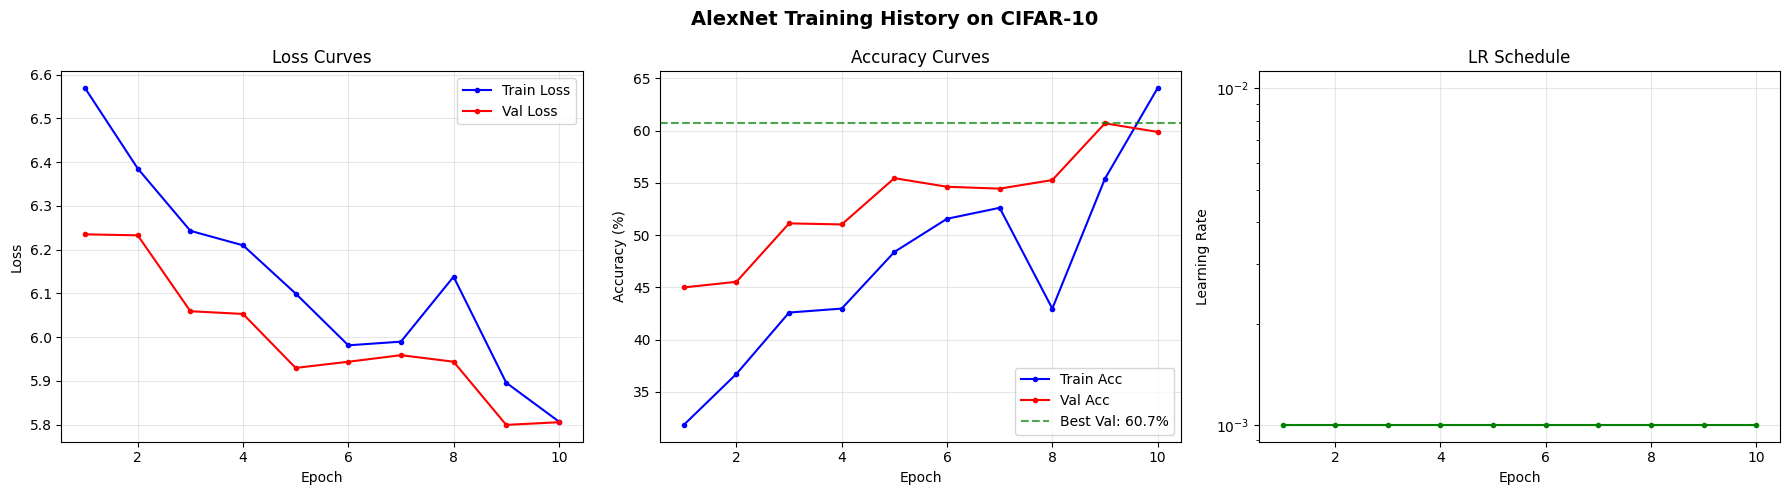

In [ ]:
hist       = history.history
epochs_ran = range(1, len(hist['accuracy']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AlexNet Training History on CIFAR-10', fontsize=14, fontweight='bold')

# ── Loss ──
ax = axes[0]
ax.plot(epochs_ran, hist['loss'],     'b-o', ms=3, label='Train Loss')
ax.plot(epochs_ran, hist['val_loss'], 'r-o', ms=3, label='Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Loss Curves'); ax.legend(); ax.grid(alpha=0.3)

# ── Accuracy ──
best_val_acc = max(hist['val_accuracy']) * 100
ax = axes[1]
ax.plot(epochs_ran, [v*100 for v in hist['accuracy']],     'b-o', ms=3, label='Train Acc')
ax.plot(epochs_ran, [v*100 for v in hist['val_accuracy']], 'r-o', ms=3, label='Val Acc')
ax.axhline(best_val_acc, ls='--', color='green', alpha=0.7,
           label=f'Best Val: {best_val_acc:.1f}%')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy Curves'); ax.legend(); ax.grid(alpha=0.3)

# ── Learning Rate ──
ax = axes[2]
# Fix: Try tracking 'learning_rate' first, fallback to 'lr' if not found
lr_key = 'learning_rate' if 'learning_rate' in hist else 'lr'

if lr_key in hist:
    ax.plot(epochs_ran, hist[lr_key], 'g-o', ms=3)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
    ax.set_title('LR Schedule'); ax.set_yscale('log'); ax.grid(alpha=0.3)
else:
    # If no LR was logged at all, print a helpful warning on the blank plot
    ax.text(0.5, 0.5, 'No LR history found\n(Add an LR Scheduler callback)',
            ha='center', va='center', fontsize=10, color='red')
    ax.set_title('LR Schedule')

plt.tight_layout()
plt.show()

## Step 13: Load Best Model & Evaluate on Test Set

In [ ]:
# Load the best checkpoint saved during training
best_model = keras.models.load_model(CONFIG['save_path'])
print(f"Loaded best model from: {CONFIG['save_path']}")

test_loss, test_acc = best_model.evaluate(
    x_test, y_test_oh,
    batch_size=CONFIG['batch_size'],
    verbose=0
)

print()
print("╔══════════════════════════════════╗")
print("║         FINAL TEST RESULTS       ║")
print("╠══════════════════════════════════╣")
print(f"║  Test Loss     : {test_loss:>8.4f}         ║")
print(f"║  Test Accuracy : {test_acc*100:>7.2f}%         ║")
print("╚══════════════════════════════════╝")

Loaded best model from: alexnet_cifar10_best.keras

╔══════════════════════════════════╗
║         FINAL TEST RESULTS       ║
╠══════════════════════════════════╣
║  Test Loss     :   5.8061         ║
║  Test Accuracy :   59.99%         ║
╚══════════════════════════════════╝


## Step 14: Confusion Matrix

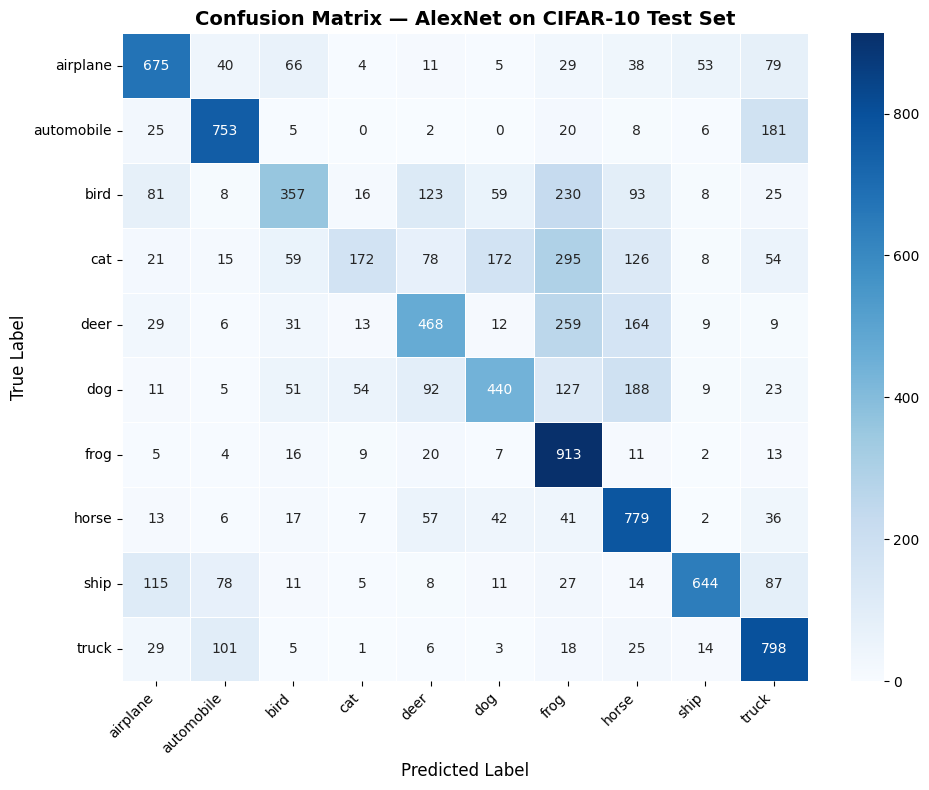

In [ ]:
# Get predictions on full test set
y_pred_probs = best_model.predict(x_test, batch_size=CONFIG['batch_size'], verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — AlexNet on CIFAR-10 Test Set',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 15: Per-Class Classification Report

In [ ]:
report = classification_report(y_true, y_pred,
                                target_names=CLASS_NAMES, digits=3)
print("Classification Report")
print("=" * 60)
print(report)

Classification Report
              precision    recall  f1-score   support

    airplane      0.672     0.675     0.674      1000
  automobile      0.741     0.753     0.747      1000
        bird      0.578     0.357     0.441      1000
         cat      0.612     0.172     0.269      1000
        deer      0.541     0.468     0.502      1000
         dog      0.586     0.440     0.503      1000
        frog      0.466     0.913     0.617      1000
       horse      0.539     0.779     0.637      1000
        ship      0.853     0.644     0.734      1000
       truck      0.611     0.798     0.692      1000

    accuracy                          0.600     10000
   macro avg      0.620     0.600     0.582     10000
weighted avg      0.620     0.600     0.582     10000



## Step 16: Per-Class Accuracy Bar Chart

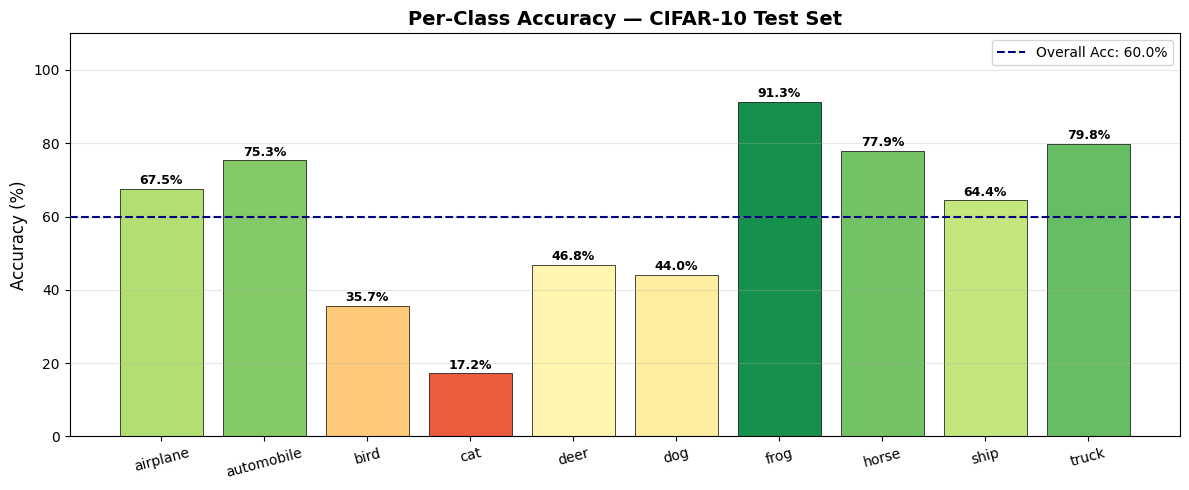

In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

colors = plt.cm.RdYlGn(per_class_acc / 100)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(CLASS_NAMES, per_class_acc, color=colors,
              edgecolor='black', linewidth=0.5)

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.axhline(test_acc * 100, ls='--', color='navy', lw=1.5,
           label=f'Overall Acc: {test_acc*100:.1f}%')
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Accuracy — CIFAR-10 Test Set',
             fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Step 17: Visualize Predictions on Test Images

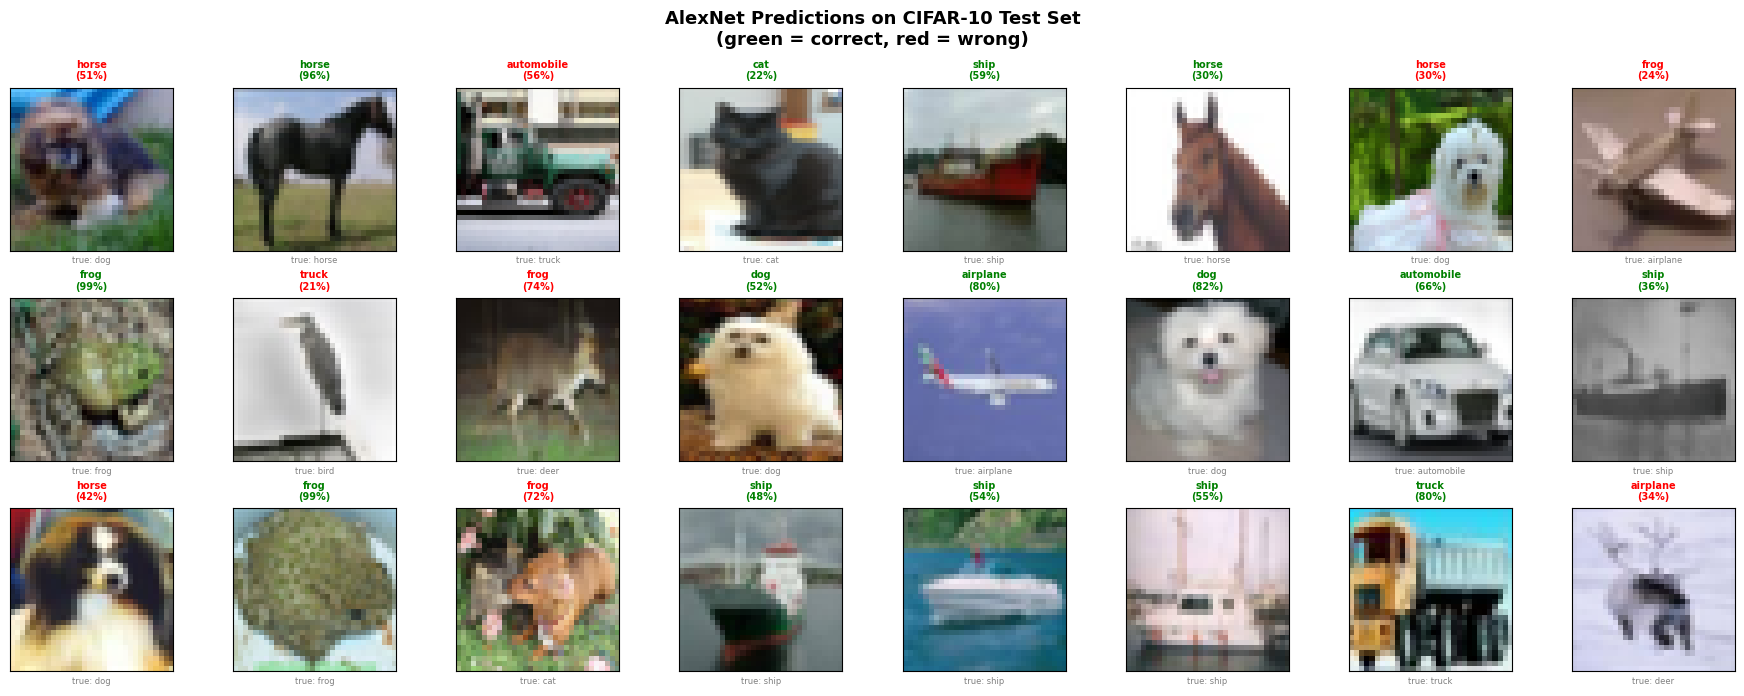

In [ ]:
# Sample 24 random test images
indices = np.random.choice(len(x_test), 24, replace=False)
sample_x = x_test[indices]
sample_y = y_true[indices]

pred_probs = best_model.predict(sample_x, verbose=0)
pred_cls   = np.argmax(pred_probs, axis=1)

fig, axes = plt.subplots(3, 8, figsize=(18, 7))
fig.suptitle('AlexNet Predictions on CIFAR-10 Test Set\n(green = correct, red = wrong)',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(sample_x[i]))
    true_name = CLASS_NAMES[sample_y[i]]
    pred_name = CLASS_NAMES[pred_cls[i]]
    conf      = pred_probs[i][pred_cls[i]] * 100
    color     = 'green' if pred_cls[i] == sample_y[i] else 'red'
    ax.set_title(f'{pred_name}\n({conf:.0f}%)', fontsize=7,
                 color=color, fontweight='bold')
    ax.set_xlabel(f'true: {true_name}', fontsize=6, color='gray')
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

## Step 18: Visualize Conv1 Learned Filters

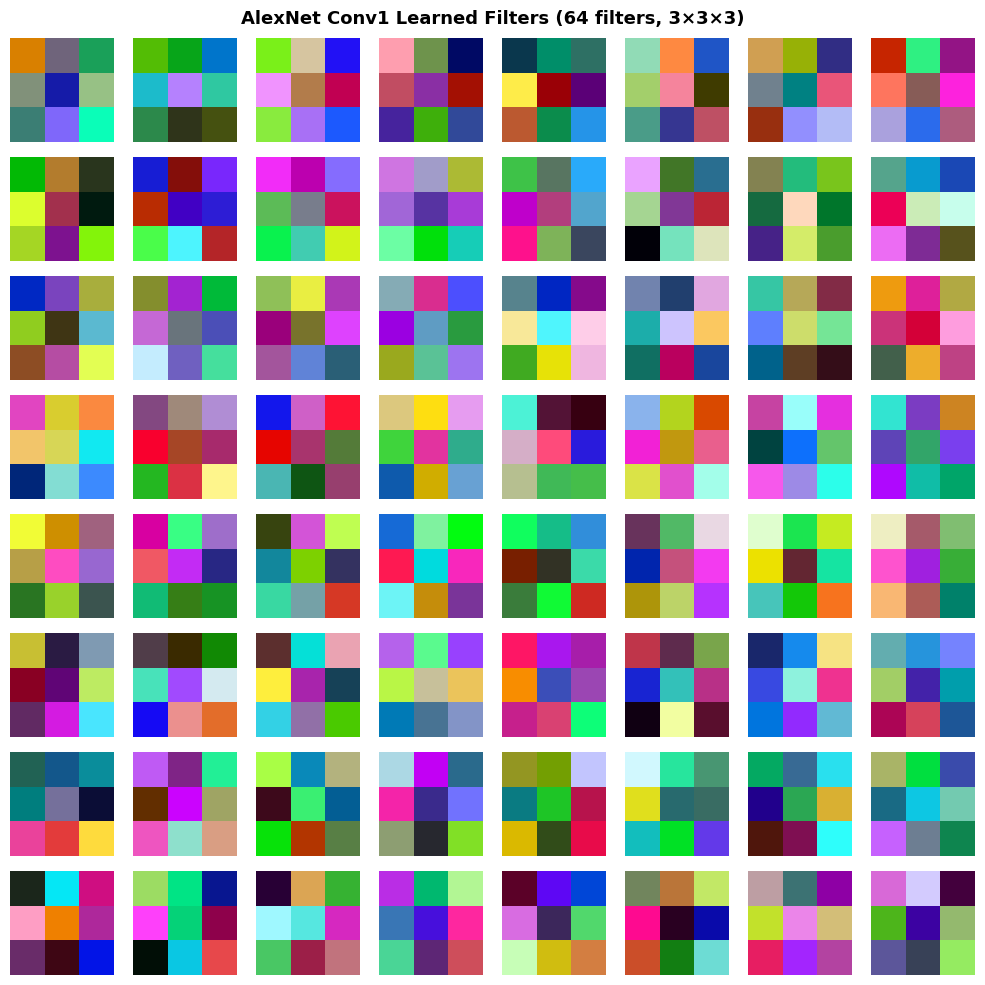

Filters reveal learned edge detectors, color blobs, and texture patterns.


In [ ]:
# Extract Conv1 weights: shape (3, 3, 3, 64) → 64 filters of size 3×3×3
conv1_weights = best_model.get_layer('conv1').get_weights()[0]  # (3, 3, 3, 64)

def normalize_filter(f):
    f = f - f.min()
    f = f / (f.max() + 1e-8)
    return f

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
fig.suptitle('AlexNet Conv1 Learned Filters (64 filters, 3×3×3)',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < conv1_weights.shape[-1]:
        filt = normalize_filter(conv1_weights[:, :, :, i])
        ax.imshow(filt, interpolation='nearest')
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Filters reveal learned edge detectors, color blobs, and texture patterns.")

## Step 19: Visualize Intermediate Feature Maps

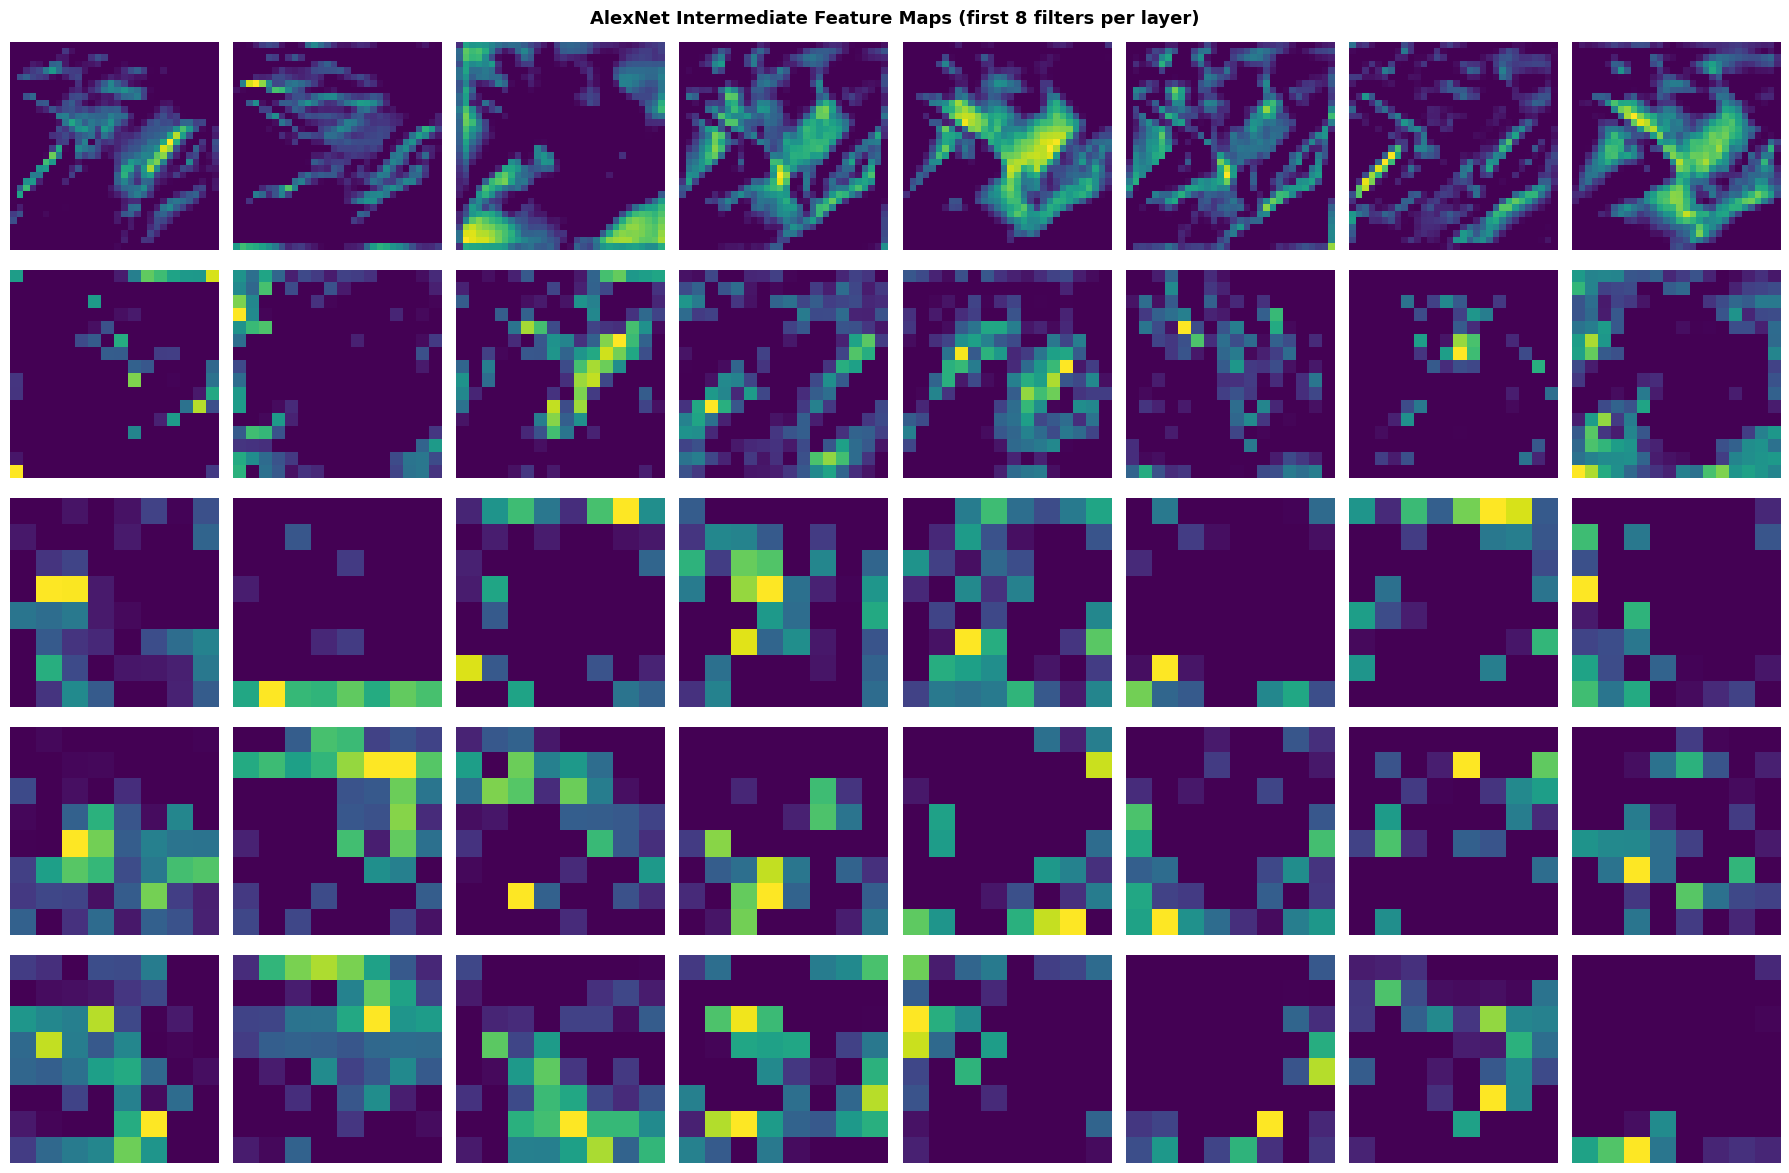

In [ ]:
# Build a sub-model that outputs intermediate activations
layer_names   = ['relu1', 'relu2', 'relu3', 'relu4', 'relu5']
layer_outputs = [best_model.get_layer(n).output for n in layer_names]
activation_model = keras.Model(inputs=best_model.input, outputs=layer_outputs)

# Pick one test image
sample_img = x_test[np.random.randint(len(x_test))]
activations = activation_model.predict(
    sample_img[np.newaxis, ...], verbose=0)

fig, axes = plt.subplots(5, 8, figsize=(18, 12))
fig.suptitle('AlexNet Intermediate Feature Maps (first 8 filters per layer)',
             fontsize=13, fontweight='bold')

for row, (act, name) in enumerate(zip(activations, layer_names)):
    for col in range(8):
        ax = axes[row, col]
        fmap = act[0, :, :, col]
        ax.imshow(fmap, cmap='viridis', interpolation='nearest')
        if col == 0:
            ax.set_ylabel(name, fontsize=9, rotation=0,
                          labelpad=50, va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()

## Step 20: Single-Image Top-5 Prediction Demo

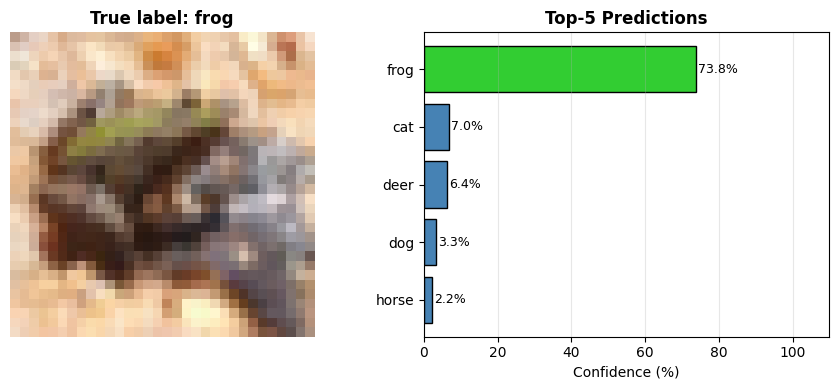

In [ ]:
def predict_top5(model, image, class_names):
    """Return top-5 (class_name, confidence%) for a single image."""
    probs   = model.predict(image[np.newaxis, ...], verbose=0).squeeze()
    top5_idx = np.argsort(probs)[::-1][:5]
    return [(class_names[i], probs[i] * 100) for i in top5_idx]

# Random test image
idx       = np.random.randint(len(x_test))
img       = x_test[idx]
true_lbl  = y_true[idx]

top5 = predict_top5(best_model, img, CLASS_NAMES)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

ax1.imshow(denormalize(img))
ax1.set_title(f'True label: {CLASS_NAMES[true_lbl]}',
              fontsize=12, fontweight='bold')
ax1.axis('off')

names, confs = zip(*top5)
bar_colors   = ['limegreen' if n == CLASS_NAMES[true_lbl] else 'steelblue'
                for n in names]
ax2.barh(names[::-1], confs[::-1], color=bar_colors[::-1], edgecolor='black')
ax2.set_xlabel('Confidence (%)')
ax2.set_title('Top-5 Predictions', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 110)
for j, (n, c) in enumerate(zip(names[::-1], confs[::-1])):
    ax2.text(c + 0.5, j, f'{c:.1f}%', va='center', fontsize=9)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()